In [1]:
pip install segyio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 5.6 MB/s eta 0:00:00


In [2]:
import segyio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
segy_path = Path("/content/drive/MyDrive/Stratton Project/Data/seismic/Stratton3D_32bit.sgy")

In [5]:
# Opening SEG-Y file: ignore_geometry used for older or non-standard 3D volumes

with segyio.open(str(segy_path), ignore_geometry=True) as f:

    # Basic survey information
    n_traces   = f.tracecount                 # number of seismic traces
    n_samples  = f.samples.size               # time samples per trace
    dt_ms      = segyio.tools.dt(f) / 1000    # sample interval in ms
    twt        = f.samples                    # array of two-way times (ms)

    print("\n--- Survey basics ---")
    print(f"Number of traces      : {n_traces}")
    print(f"Samples per trace     : {n_samples}")
    print(f"Sample rate           : {dt_ms:.2f} ms")
    print(f"Time range            : {twt[0]:.0f} – {twt[-1]:.0f} ms")

    # --- Binary header (survey-wide settings) ---
    print("\n--- Selected binary header fields ---")
    print(f"Data format code      : {f.bin[segyio.BinField.Format]}")
    print(f"Samples (from bin)    : {f.bin[segyio.BinField.Samples]}")
    # Format code 1 = IBM float, 5 = IEEE float (most modern files use 5)

    # --- Read a small amount of data for QC, not loading the whole cube yet ---
    data_sample = f.trace.raw[:500]           # first 500 traces only
    print(f"\nSample data shape     : {data_sample.shape}")   # (500, n_samples)
    print(f"Amplitude min / max   : {data_sample.min():.1f} / {data_sample.max():.1f}")


--- Survey basics ---
Number of traces      : 71070
Samples per trace     : 1501
Sample rate           : 2.00 ms
Time range            : 0 – 3000 ms

--- Selected binary header fields ---
Data format code      : 1
Samples (from bin)    : 1501

Sample data shape     : (500, 1501)
Amplitude min / max   : -5445.0 / 5175.0


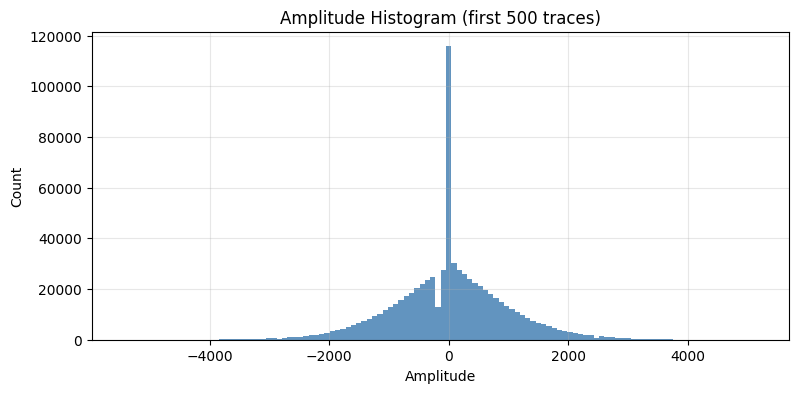

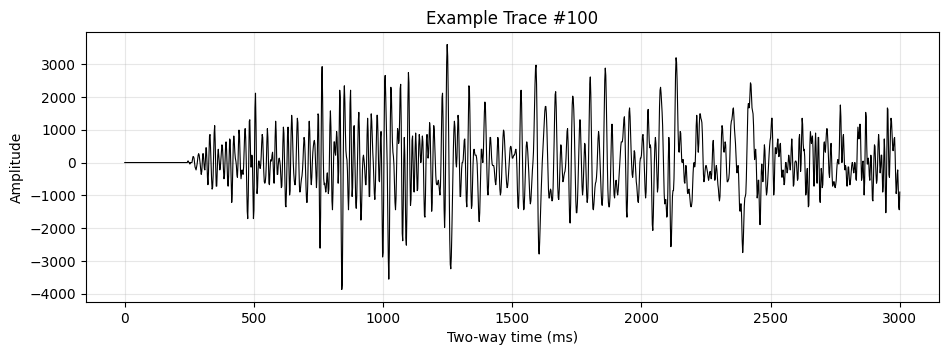

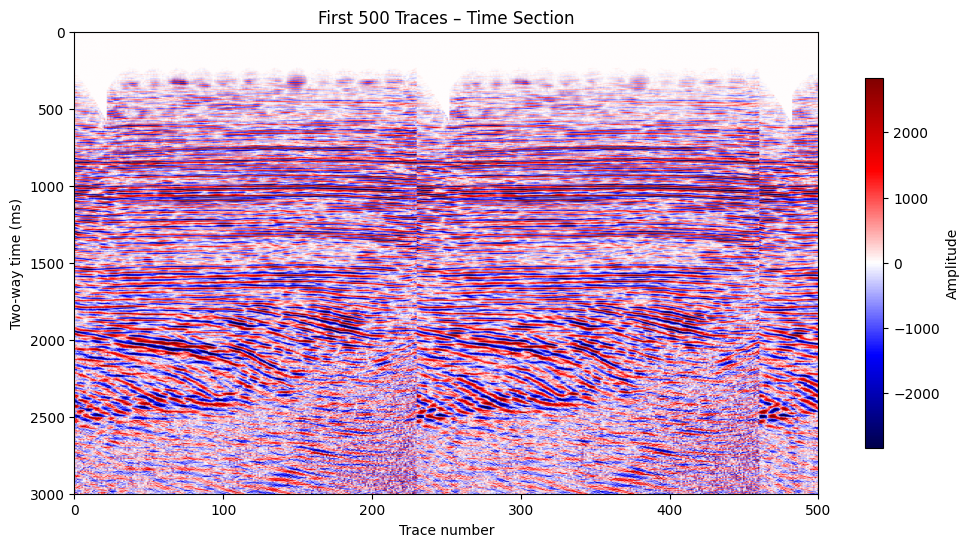

In [6]:
#QC Plots

# Amplitude histogram
plt.figure(figsize=(9, 4))
plt.hist(data_sample.flatten(), bins=120, color="steelblue", alpha=0.85)
plt.title("Amplitude Histogram (first 500 traces)")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

# Individual trace
plt.figure(figsize=(11, 3.5))
plt.plot(twt, data_sample[100], color="black", linewidth=0.8)
plt.title("Example Trace #100")
plt.xlabel("Two-way time (ms)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

# Time section
clip = np.percentile(np.abs(data_sample), 99)   # robust clipping

plt.figure(figsize=(12, 6))
plt.imshow(data_sample.T,                       # transpose so time is vertical
           aspect="auto",
           cmap="seismic",
           vmin=-clip, vmax=clip,
           extent=[0, data_sample.shape[0], twt[-1], twt[0]])  # x = traces, y = time
plt.title("First 500 Traces – Time Section")
plt.xlabel("Trace number")
plt.ylabel("Two-way time (ms)")
plt.colorbar(label="Amplitude", shrink=0.8)
plt.show()

In [7]:
print("Amplitude statistics (first 500 traces):")
print(f"  Min          : {data_sample.min():.1f}")
print(f"  Max          : {data_sample.max():.1f}")
print(f"  Mean         : {data_sample.mean():.2f}")
print(f"  Std          : {data_sample.std():.1f}")
print(f"  1st percentile: {np.percentile(data_sample, 1):.1f}")
print(f"  99th percentile: {np.percentile(data_sample, 99):.1f}")
print(f"  99.9th percentile: {np.percentile(data_sample, 99.9):.1f}")

Amplitude statistics (first 500 traces):
  Min          : -5445.0
  Max          : 5175.0
  Mean         : 19.55
  Std          : 959.1
  1st percentile: -2475.0
  99th percentile: 2520.0
  99.9th percentile: 3555.0


In [8]:
with segyio.open(str(segy_path), ignore_geometry=True) as f:

    # Looking at the first few trace headers to find likely inline / crossline byte locations
    print("First 10 traces – selected header fields:")
    print(f"{'Trace':>6} | {'Field 189':>10} | {'Field 193':>10} | {'CDP':>8} | {'INLINE':>8} | {'XLINE':>8}")
    print("-" * 65)

    for i in range(10):
        f189 = f.header[i][189]
        f193 = f.header[i][193]
        cdp  = f.header[i][segyio.TraceField.CDP]
        # These two are the official segyio names
        il   = f.header[i][segyio.TraceField.INLINE_3D]
        xl   = f.header[i][segyio.TraceField.CROSSLINE_3D]

        print(f"{i:6d} | {f189:10d} | {f193:10d} | {cdp:8d} | {il:8d} | {xl:8d}")

First 10 traces – selected header fields:
 Trace |  Field 189 |  Field 193 |      CDP |   INLINE |    XLINE
-----------------------------------------------------------------
     0 |          0 |          0 |        1 |        0 |        0
     1 |          0 |          0 |        2 |        0 |        0
     2 |          0 |          0 |        3 |        0 |        0
     3 |          0 |          0 |        4 |        0 |        0
     4 |          0 |          0 |        5 |        0 |        0
     5 |          0 |          0 |        6 |        0 |        0
     6 |          0 |          0 |        7 |        0 |        0
     7 |          0 |          0 |        8 |        0 |        0
     8 |          0 |          0 |        9 |        0 |        0
     9 |          0 |          0 |       10 |        0 |        0


In [9]:
with segyio.open(str(segy_path), ignore_geometry=True) as f:
    # Collect a few important headers for all traces (this is still fast)
    cdps = f.attributes(segyio.TraceField.CDP)[:]
    ils  = f.attributes(segyio.TraceField.INLINE_3D)[:]
    xls  = f.attributes(segyio.TraceField.CROSSLINE_3D)[:]

    print("\nCDP      min/max:", cdps.min(), cdps.max())
    print("INLINE_3D min/max:", ils.min(), ils.max())
    print("CROSSLINE_3D min/max:", xls.min(), xls.max())


CDP      min/max: 1 230
INLINE_3D min/max: 0 0
CROSSLINE_3D min/max: 0 0


In [10]:
# For this cell, we need to find where the inline is stored. The previous 2 cells showed that the crossline is the CDP number.

with segyio.open(str(segy_path), ignore_geometry=True) as f:
    print(f"{'Tr':>4} | {'CDP':>6} | {'FieldRecord':>12} | {'EnergySource':>12} | {'TRACE_NUMBER':>12}")
    print("-" * 60)
    for i in range(20):
        cdp  = f.header[i][segyio.TraceField.CDP]
        fldr = f.header[i][segyio.TraceField.FieldRecord]
        ep   = f.header[i][segyio.TraceField.EnergySourcePoint]
        trnr = f.header[i][segyio.TraceField.TRACE_SEQUENCE_FILE]
        print(f"{i:4d} | {cdp:6d} | {fldr:12d} | {ep:12d} | {trnr:12d}")

  Tr |    CDP |  FieldRecord | EnergySource | TRACE_NUMBER
------------------------------------------------------------
   0 |      1 |            2 |            0 |            0
   1 |      2 |            2 |            0 |            0
   2 |      3 |            2 |            0 |            0
   3 |      4 |            2 |            0 |            0
   4 |      5 |            2 |            0 |            0
   5 |      6 |            2 |            0 |            0
   6 |      7 |            2 |            0 |            0
   7 |      8 |            2 |            0 |            0
   8 |      9 |            2 |            0 |            0
   9 |     10 |            2 |            0 |            0
  10 |     11 |            2 |            0 |            0
  11 |     12 |            2 |            0 |            0
  12 |     13 |            2 |            0 |            0
  13 |     14 |            2 |            0 |            0
  14 |     15 |            2 |            0 |         

In [11]:
# Here we will get the full ranges

with segyio.open(str(segy_path), ignore_geometry=True) as f:
    cdps  = f.attributes(segyio.TraceField.CDP)[:]
    fldrs = f.attributes(segyio.TraceField.FieldRecord)[:]
    eps   = f.attributes(segyio.TraceField.EnergySourcePoint)[:]

    print("CDP            min/max:", cdps.min(), "→", cdps.max())
    print("FieldRecord    min/max:", fldrs.min(), "→", fldrs.max())
    print("EnergySourcePt min/max:", eps.min(), "→", eps.max())
    print()
    print("Unique CDP values     :", len(np.unique(cdps)))
    print("Unique FieldRecord    :", len(np.unique(fldrs)))
    print("Unique EnergySourcePt :", len(np.unique(eps)))

CDP            min/max: 1 → 230
FieldRecord    min/max: 2 → 310
EnergySourcePt min/max: 0 → 0

Unique CDP values     : 230
Unique FieldRecord    : 309
Unique EnergySourcePt : 1


In [12]:
# 3D Cube

with segyio.open(str(segy_path), ignore_geometry=True) as f:
    # Read all data
    data = f.trace.raw[:]                     # shape (71070, 1501)

    # Get the headers we need
    inlines    = f.attributes(segyio.TraceField.FieldRecord)[:]
    crosslines = f.attributes(segyio.TraceField.CDP)[:]
    twt        = f.samples                    # time axis in ms

# Sort the traces into a proper 3D cube
# We create an empty cube and fill it
unique_ils = np.unique(inlines)
unique_xls = np.unique(crosslines)

n_il = len(unique_ils)      # 309
n_xl = len(unique_xls)      # 230
n_samples = data.shape[1]   # 1501

cube = np.zeros((n_il, n_xl, n_samples), dtype=np.float32)

# Create lookup dictionaries for speed
il_idx = {il: i for i, il in enumerate(unique_ils)}
xl_idx = {xl: i for i, xl in enumerate(unique_xls)}

for i in range(len(data)):
    il = inlines[i]
    xl = crosslines[i]
    cube[il_idx[il], xl_idx[xl], :] = data[i]

print("Cube shape (inline, crossline, time):", cube.shape)
print("Inline range   :", unique_ils.min(), "→", unique_ils.max())
print("Crossline range:", unique_xls.min(), "→", unique_xls.max())
print("Memory used    :", round(cube.nbytes / 1e6, 1), "MB")

Cube shape (inline, crossline, time): (309, 230, 1501)
Inline range   : 2 → 310
Crossline range: 1 → 230
Memory used    : 426.7 MB


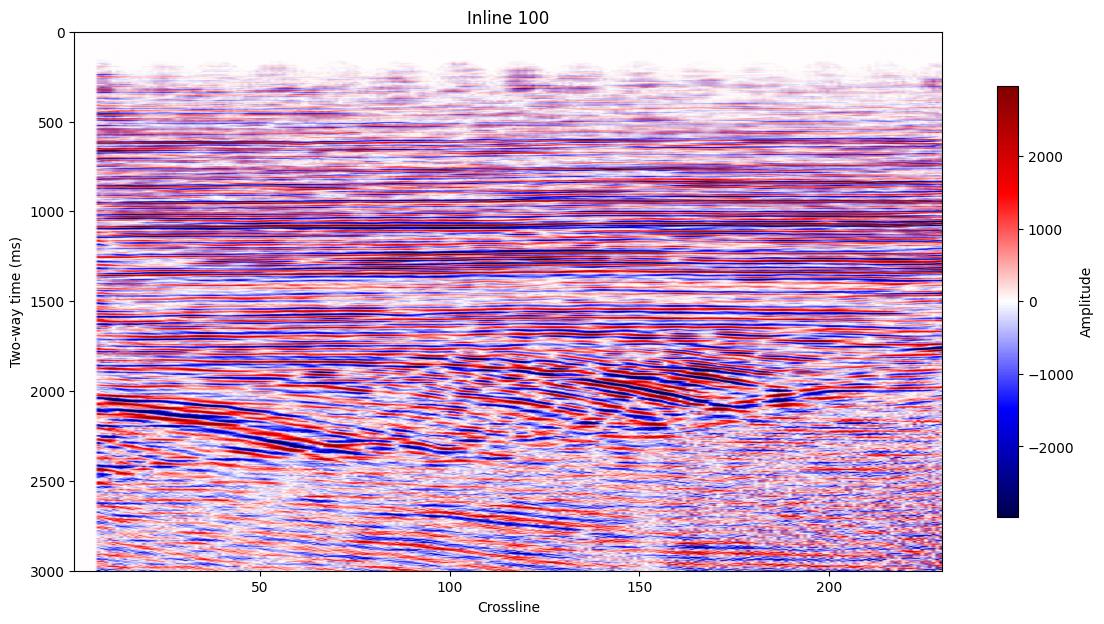

In [13]:
# One inline

il_to_plot = 100          # choosing any inline between 2 and 310
il_index = il_idx[il_to_plot]

section = cube[il_index, :, :].T          # shape (time, crossline)

clip = np.percentile(np.abs(section), 99)

plt.figure(figsize=(14, 7))
plt.imshow(section, aspect='auto', cmap='seismic',
           vmin=-clip, vmax=clip,
           extent=[unique_xls.min(), unique_xls.max(), twt[-1], twt[0]])
plt.title(f"Inline {il_to_plot}")
plt.xlabel("Crossline")
plt.ylabel("Two-way time (ms)")
plt.colorbar(label="Amplitude", shrink=0.8)
plt.show()

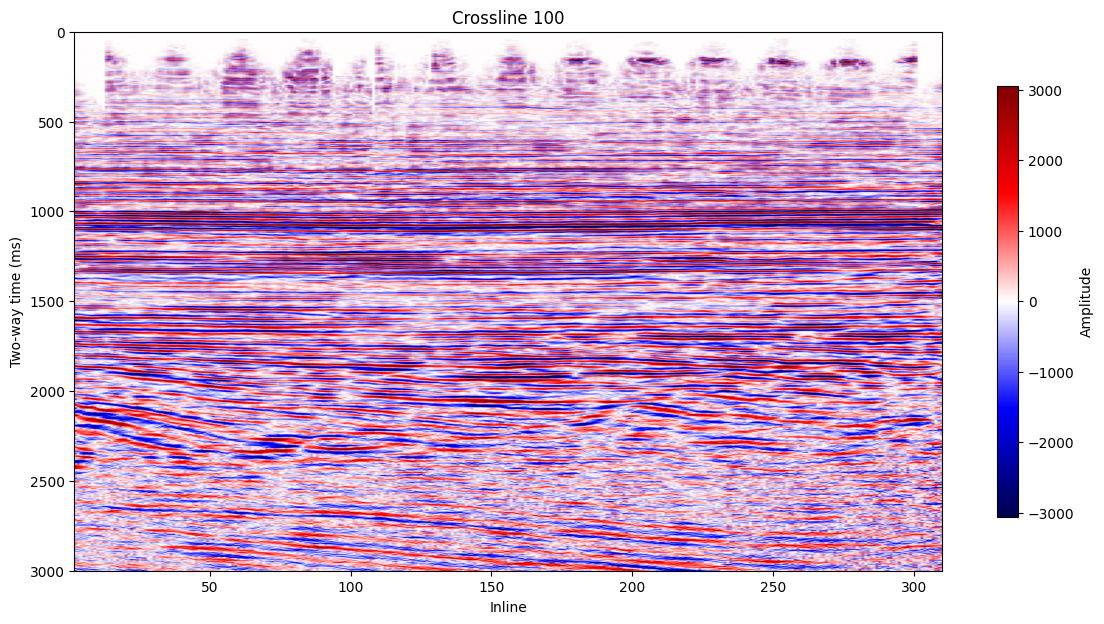

In [14]:
# One crossline

xl_to_plot = 100
xl_index = xl_idx[xl_to_plot]

section = cube[:, xl_index, :].T

clip = np.percentile(np.abs(section), 99)

plt.figure(figsize=(14, 7))
plt.imshow(section, aspect='auto', cmap='seismic',
           vmin=-clip, vmax=clip,
           extent=[unique_ils.min(), unique_ils.max(), twt[-1], twt[0]])
plt.title(f"Crossline {xl_to_plot}")
plt.xlabel("Inline")
plt.ylabel("Two-way time (ms)")
plt.colorbar(label="Amplitude", shrink=0.8)
plt.show()

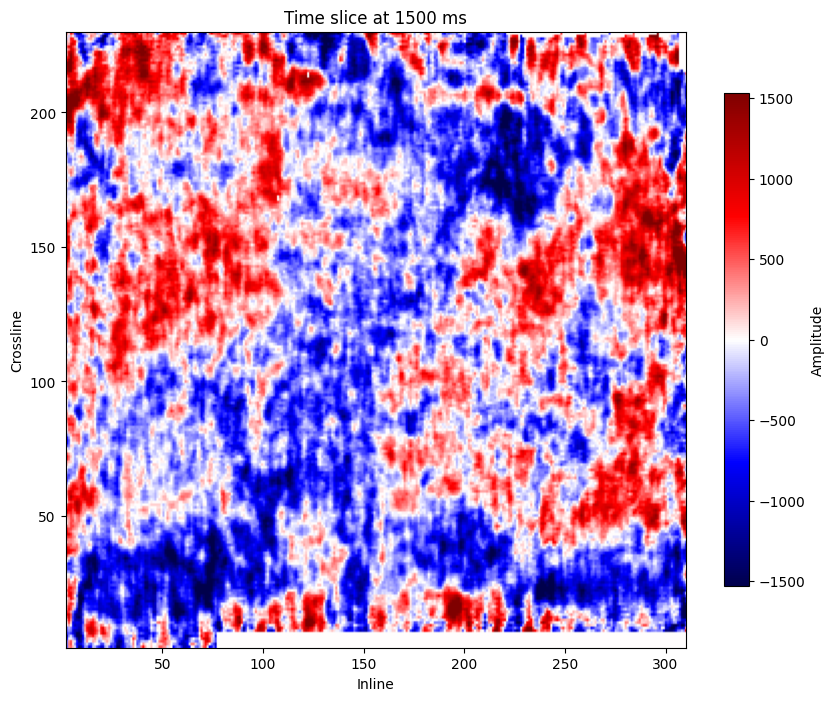

In [15]:
# Time slice

time_ms = 1500            # choose any time between 0 and 3000
t_index = np.argmin(np.abs(twt - time_ms))

slice_ = cube[:, :, t_index]

clip = np.percentile(np.abs(slice_), 99)

plt.figure(figsize=(10, 8))
plt.imshow(slice_.T, aspect='auto', cmap='seismic',
           vmin=-clip, vmax=clip,
           origin='lower',
           extent=[unique_ils.min(), unique_ils.max(),
                   unique_xls.min(), unique_xls.max()])
plt.title(f"Time slice at {twt[t_index]:.0f} ms")
plt.xlabel("Inline")
plt.ylabel("Crossline")
plt.colorbar(label="Amplitude", shrink=0.8)
plt.show()

In [16]:
# Computing RMS amplitude

def rms_amplitude(cube, twt, window_ms):
    """
    Compute RMS amplitude in a sliding or fixed window.
    window_ms = (start_time, end_time) in milliseconds
    """
    t1, t2 = window_ms
    idx1 = np.argmin(np.abs(twt - t1))
    idx2 = np.argmin(np.abs(twt - t2))

    window_data = cube[:, :, idx1:idx2+1]
    rms = np.sqrt(np.mean(window_data**2, axis=2))
    return rms

# Example windows (these can be changed)
rms_shallow = rms_amplitude(cube, twt, (800, 1200))    # shallow section
rms_mid     = rms_amplitude(cube, twt, (1400, 1800))    # mid section
rms_deep    = rms_amplitude(cube, twt, (2000, 2400))    # deeper section

print("RMS volumes shape:", rms_mid.shape)   # should be (309, 230)

RMS volumes shape: (309, 230)


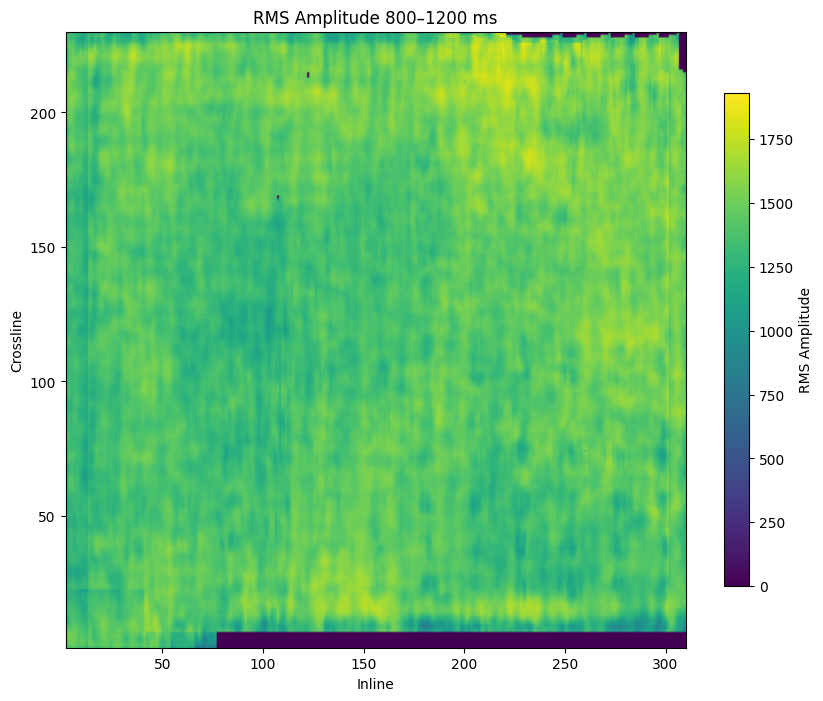

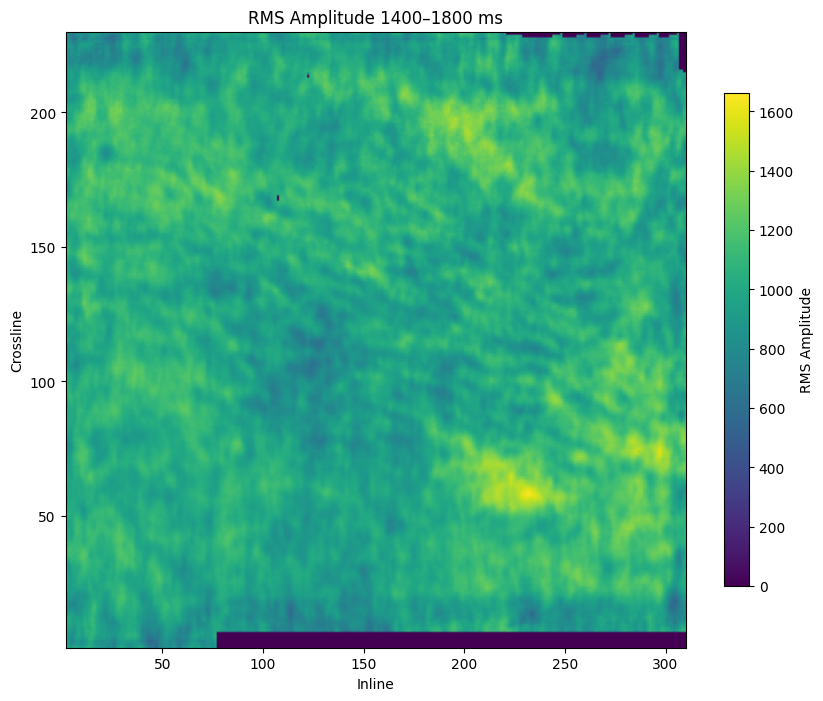

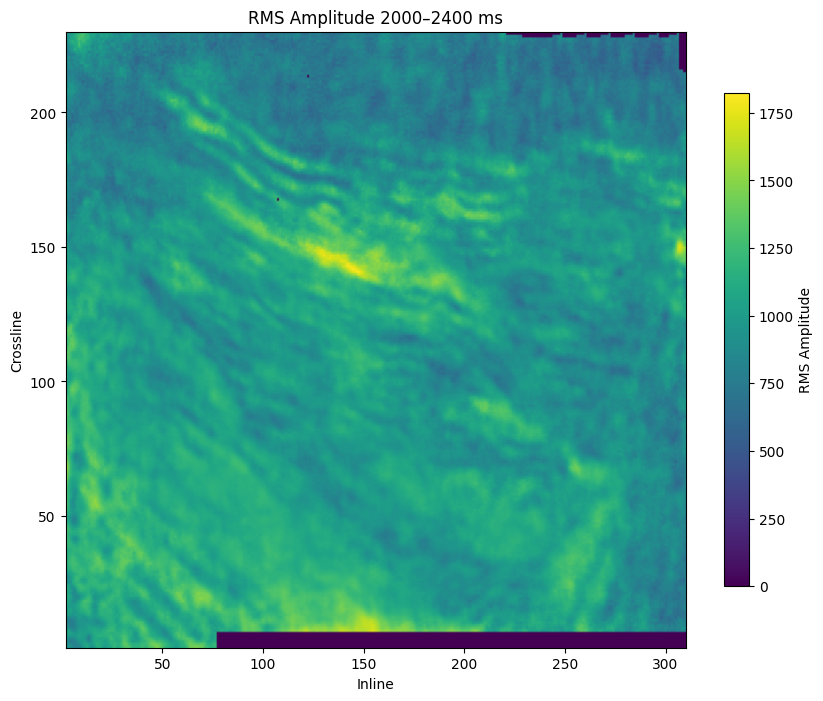

In [17]:
# RMS Maps

def plot_rms(rms, title, unique_ils, unique_xls):
    plt.figure(figsize=(10, 8))
    im = plt.imshow(rms.T, origin='lower', aspect='auto', cmap='viridis',
                    extent=[unique_ils.min(), unique_ils.max(),
                            unique_xls.min(), unique_xls.max()])
    plt.title(title)
    plt.xlabel("Inline")
    plt.ylabel("Crossline")
    plt.colorbar(im, label="RMS Amplitude", shrink=0.8)
    plt.show()

plot_rms(rms_shallow, "RMS Amplitude 800–1200 ms", unique_ils, unique_xls)
plot_rms(rms_mid,     "RMS Amplitude 1400–1800 ms", unique_ils, unique_xls)
plot_rms(rms_deep,    "RMS Amplitude 2000–2400 ms", unique_ils, unique_xls)

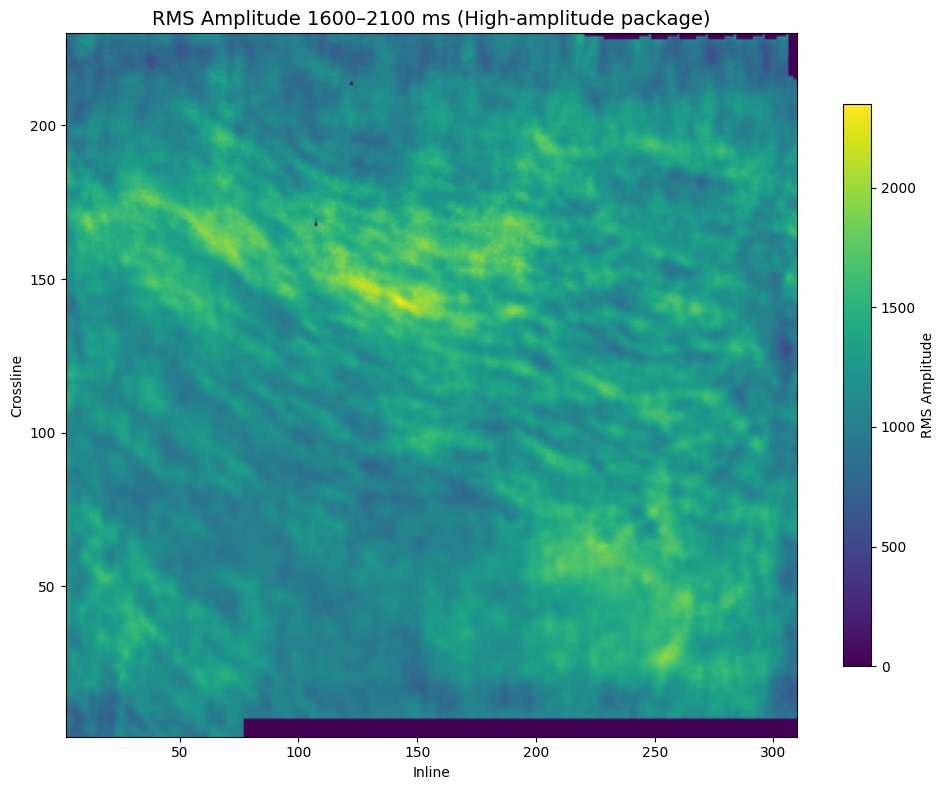

In [18]:
#Figure 1

# Tighter window focused on the high-amplitude package
rms_package = rms_amplitude(cube, twt, (1600, 2100))

# --- Self-contained plot + save ---
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(rms_package.T, origin='lower', aspect='auto', cmap='viridis',
               extent=[unique_ils.min(), unique_ils.max(),
                       unique_xls.min(), unique_xls.max()])

ax.set_title("RMS Amplitude 1600–2100 ms (High-amplitude package)", fontsize=14)
ax.set_xlabel("Inline")
ax.set_ylabel("Crossline")

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("RMS Amplitude")

# Make sure everything is rendered
fig.tight_layout()
fig.canvas.draw()

# Save
fig.savefig("/content/drive/MyDrive/Stratton Project/Figures/fig1_rms_map.png",
            dpi=200, bbox_inches="tight", facecolor="white")

plt.show()

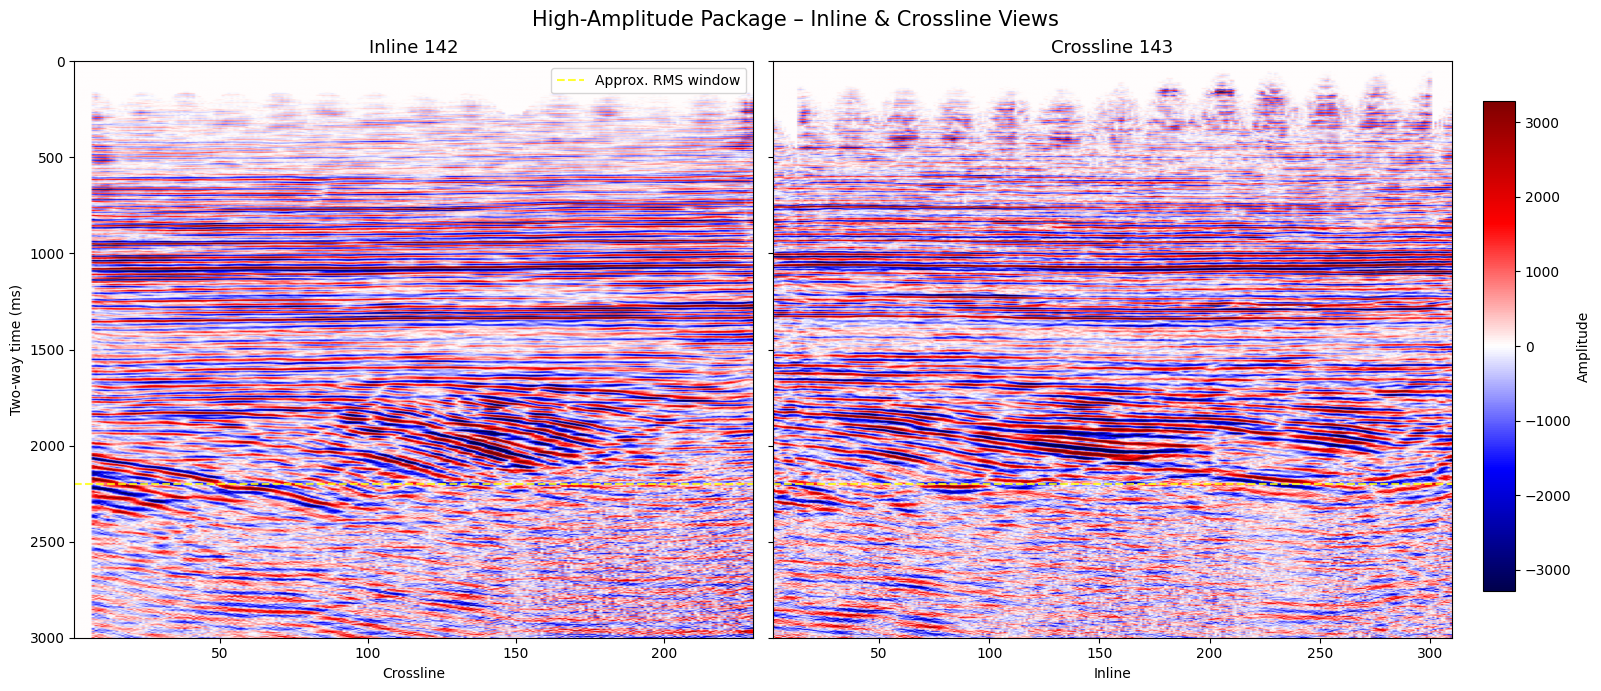

In [20]:
# Figure 2

# --- Figure 2: Inline + Crossline (fixed colorbar) ---

il_to_plot = 142
xl_to_plot = 143

il_index = il_idx[il_to_plot]
xl_index = xl_idx[xl_to_plot]

section_il = cube[il_index, :, :].T
section_xl = cube[:, xl_index, :].T

clip_il = np.percentile(np.abs(section_il), 99)
clip_xl = np.percentile(np.abs(section_xl), 99)

# Create figure with extra space on the right for the colorbar
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# --- Inline ---
im0 = axes[0].imshow(section_il, aspect='auto', cmap='seismic',
                     vmin=-clip_il, vmax=clip_il,
                     extent=[unique_xls.min(), unique_xls.max(), twt[-1], twt[0]])
axes[0].axhline(2200, color='yellow', linestyle='--', alpha=0.8, label='Approx. RMS window')
axes[0].set_title(f"Inline {il_to_plot}", fontsize=13)
axes[0].set_xlabel("Crossline")
axes[0].set_ylabel("Two-way time (ms)")
axes[0].legend(loc='upper right')

# --- Crossline ---
im1 = axes[1].imshow(section_xl, aspect='auto', cmap='seismic',
                     vmin=-clip_xl, vmax=clip_xl,
                     extent=[unique_ils.min(), unique_ils.max(), twt[-1], twt[0]])
axes[1].axhline(2200, color='yellow', linestyle='--', alpha=0.8)
axes[1].set_title(f"Crossline {xl_to_plot}", fontsize=13)
axes[1].set_xlabel("Inline")

# Adjust layout first, then add colorbar in the remaining space
fig.tight_layout(rect=[0, 0, 0.92, 0.96])   # leave room on the right

# Colorbar on the right side of the figure
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])   # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label("Amplitude")

fig.suptitle("High-Amplitude Package – Inline & Crossline Views", fontsize=15, y=0.98)

# Save
fig.canvas.draw()
# fig.savefig("/content/drive/MyDrive/Stratton Project/Figures/fig2_inline_crossline.png",
#             dpi=200, bbox_inches="tight", facecolor="white")

plt.show()

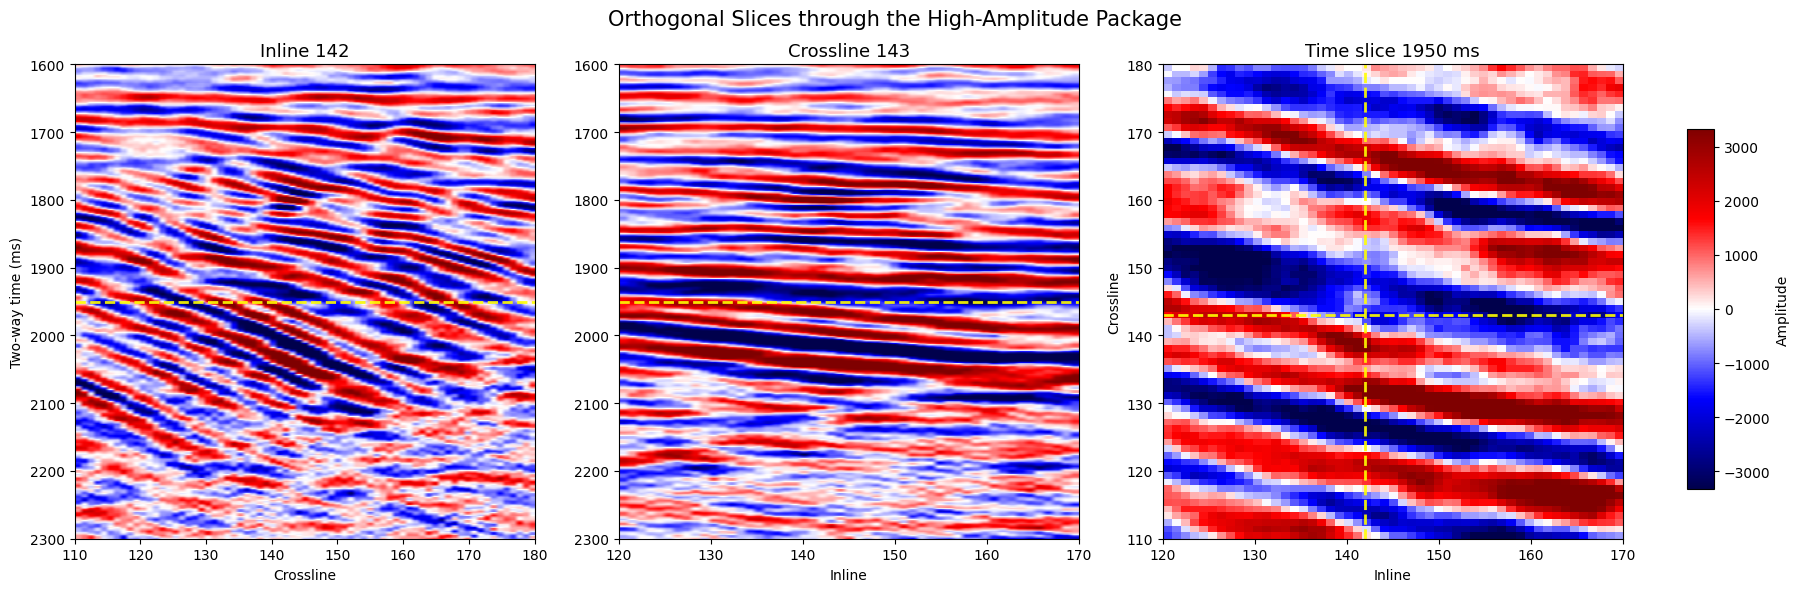

In [22]:
# Figure 3

# --- Figure 3: Orthogonal slices (Inline, Crossline, Time slice) ---

# Sub-volume around the feature
il_start, il_end = 120, 170
xl_start, xl_end = 110, 180
t_start, t_end   = 1600, 2300

il0 = np.where(unique_ils == il_start)[0][0]
il1 = np.where(unique_ils == il_end)[0][0] + 1
xl0 = np.where(unique_xls == xl_start)[0][0]
xl1 = np.where(unique_xls == xl_end)[0][0] + 1
t0  = np.argmin(np.abs(twt - t_start))
t1  = np.argmin(np.abs(twt - t_end)) + 1

subcube = cube[il0:il1, xl0:xl1, t0:t1]
sub_ils = unique_ils[il0:il1]
sub_xls = unique_xls[xl0:xl1]
sub_twt = twt[t0:t1]

# Specific locations of interest
il_to_plot = 142
xl_to_plot = 143
t_to_plot  = 1950   # roughly middle of the package (you can change this)

il_index = np.where(sub_ils == il_to_plot)[0][0]
xl_index = np.where(sub_xls == xl_to_plot)[0][0]
t_index  = np.argmin(np.abs(sub_twt - t_to_plot))

# Data slices
section_il = subcube[il_index, :, :].T
section_xl = subcube[:, xl_index, :].T
section_ts = subcube[:, :, t_index].T

clip = np.percentile(np.abs(subcube), 98)

# --- Create figure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Inline
im0 = axes[0].imshow(section_il, aspect='auto', cmap='seismic',
                     vmin=-clip, vmax=clip,
                     extent=[sub_xls[0], sub_xls[-1], sub_twt[-1], sub_twt[0]])
axes[0].axhline(t_to_plot, color='yellow', linestyle='--', linewidth=2, alpha=0.9)
axes[0].set_title(f"Inline {il_to_plot}", fontsize=13)
axes[0].set_xlabel("Crossline")
axes[0].set_ylabel("Two-way time (ms)")

# 2. Crossline
im1 = axes[1].imshow(section_xl, aspect='auto', cmap='seismic',
                     vmin=-clip, vmax=clip,
                     extent=[sub_ils[0], sub_ils[-1], sub_twt[-1], sub_twt[0]])
axes[1].axhline(t_to_plot, color='yellow', linestyle='--', linewidth=2, alpha=0.9)
axes[1].set_title(f"Crossline {xl_to_plot}", fontsize=13)
axes[1].set_xlabel("Inline")

# 3. Time slice
im2 = axes[2].imshow(section_ts, aspect='auto', cmap='seismic',
                     vmin=-clip, vmax=clip, origin='lower',
                     extent=[sub_ils[0], sub_ils[-1], sub_xls[0], sub_xls[-1]])
axes[2].axvline(il_to_plot, color='yellow', linestyle='--', linewidth=2, alpha=0.9)
axes[2].axhline(xl_to_plot, color='yellow', linestyle='--', linewidth=2, alpha=0.9)
axes[2].set_title(f"Time slice {sub_twt[t_index]:.0f} ms", fontsize=13)
axes[2].set_xlabel("Inline")
axes[2].set_ylabel("Crossline")

# Colorbar
fig.tight_layout(rect=[0, 0, 0.92, 0.95])
cbar_ax = fig.add_axes([0.94, 0.18, 0.015, 0.6])
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label("Amplitude")

fig.suptitle("Orthogonal Slices through the High-Amplitude Package", fontsize=15, y=0.98)

# Save
fig.canvas.draw()
# fig.savefig("/content/drive/MyDrive/Stratton Project/Figures/fig3_orthogonal_slices.png",
#             dpi=200, bbox_inches="tight", facecolor="white")

plt.show()